In [1]:
# import libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
# lets import the dataset (here we are gonna use processed_datatcsv)
df = pd.read_csv("processed_data.csv")

In [3]:
df


,Unnamed: 0,clean_text,status,statement_length,num_words,vocabulary_size,avg_word_length
0,0,oh gosh,3,1.945910,0.693147,0.693147,1.386294
1,1,trouble sleeping confused mind restless heart ...,3,3.912023,1.945910,1.945910,1.945910
2,2,wrong back dear forward doubt stay restless re...,3,4.060443,2.197225,2.079442,1.791759
3,3,shifted focus something else still worried,3,3.737670,1.791759,1.791759,1.945910
4,4,restless restless month boy mean,3,3.465736,1.609438,1.386294,1.791759
...,...,...,...,...,...,...,...
52540,53040,nobody takes seriously i’ve dealt depressionan...,3,7.056175,5.164786,4.969813,1.945910
52541,53041,selfishness not feel good like not belong worl...,3,6.368187,4.532599,4.317488,1.791759
52542,53042,way sleep better ca not sleep nights meds not ...,3,3.912023,2.302585,2.079442,1.609438
52543,53043,public speaking tips hi give presentation work...,3,5.564520,3.663562,3.496508,1.945910


In [4]:
# lets drop the columns
df.drop(columns = "Unnamed: 0",inplace = True)

In [5]:
df.sample(5)


,clean_text,status,statement_length,num_words,vocabulary_size,avg_word_length
38413,anyone else done point life nothing going bad ...,1,5.170484,3.258097,3.178054,1.945910
40101,want commit suicide soon possible cant fin met...,1,5.231109,3.367296,3.258097,1.791759
27686,anytime scheduled transaction towards checking...,5,5.883322,3.951244,3.951244,1.945910
4803,sore throat right away,0,3.091042,1.386294,1.386294,1.791759
11643,sister baby think might depression cries lot w...,1,4.465908,2.639057,2.484907,1.791759


In [6]:
# here we train different Ml models and Chose the best model 
# we work with different models


In [7]:
# here we do not use the the straify  = labels 


# lets now do word to number transfromation
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop("status", axis=1),df["status"],test_size = 0.2,random_state=1)

In [8]:
xtrain.shape

(42036, 5)

In [9]:
xtest.shape

(10509, 5)

In [10]:
ytrain.shape

(42036,)

In [11]:
ytest.shape

(10509,)

In [12]:
# now lets do text to number (word embedding ) we use bag of words, TFIDF

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=15000, ngram_range=(1,1))

xtrain_unigram = cv.fit_transform(xtrain["clean_text"])
xtest_unigram = cv.transform(xtest["clean_text"])

In [14]:
xtest_unigram.shape

(10509, 15000)

In [15]:
xtrain_unigram.shape

(42036, 15000)

In [16]:
# now lets stack them 
from scipy.sparse import hstack
# numerical features
num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

xtrain_num = xtrain[num_cols].values
xtest_num = xtest[num_cols].values

# combine
xtrain_final = hstack([xtrain_unigram, xtrain_num])
xtest_final = hstack([xtest_unigram, xtest_num])

In [17]:
# now lets call our everymodels for checking there base performance
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


# Ensemble models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier

# Advanced boosting
from sklearn.neighbors import KNeighborsClassifier

# External libraries
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier


In [18]:
models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
     

    "KNN": KNeighborsClassifier(),

    "RandomForest": RandomForestClassifier(),
    "Bagging": BaggingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),

    # "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    # "LightGBM": LGBMClassifier(),
    # "CatBoost": CatBoostClassifier(verbose=0)
}

In [19]:
from sklearn.metrics import (confusion_matrix, classification_report,roc_curve, auc)


===== MultinomialNB =====
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      3291
           1       0.70      0.51      0.59      3090
           2       0.61      0.69      0.65      2122
           3       0.71      0.65      0.68       742
           4       0.67      0.75      0.70       533
           5       0.54      0.47      0.50       512
           6       0.63      0.55      0.59       219

    accuracy                           0.70     10509
   macro avg       0.66      0.65      0.65     10509
weighted avg       0.69      0.70      0.69     10509



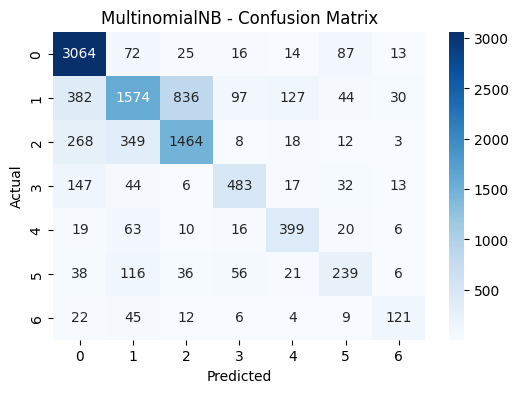


===== BernoulliNB =====
              precision    recall  f1-score   support

           0       0.64      0.92      0.76      3291
           1       0.66      0.40      0.50      3090
           2       0.53      0.50      0.52      2122
           3       0.69      0.55      0.61       742
           4       0.58      0.56      0.57       533
           5       0.43      0.44      0.43       512
           6       0.32      0.40      0.36       219

    accuracy                           0.60     10509
   macro avg       0.55      0.54      0.53     10509
weighted avg       0.61      0.60      0.59     10509



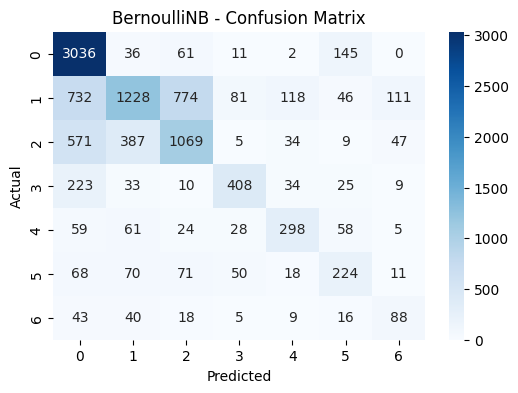


===== LogisticRegression =====
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3291
           1       0.69      0.68      0.69      3090
           2       0.64      0.62      0.63      2122
           3       0.79      0.78      0.79       742
           4       0.82      0.75      0.79       533
           5       0.60      0.52      0.55       512
           6       0.77      0.62      0.69       219

    accuracy                           0.75     10509
   macro avg       0.74      0.70      0.72     10509
weighted avg       0.75      0.75      0.75     10509



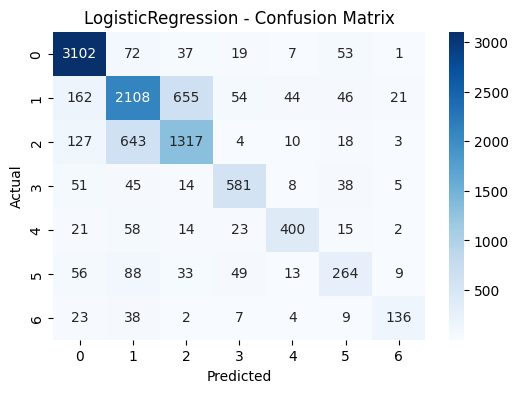


===== DecisionTree =====
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      3291
           1       0.63      0.62      0.62      3090
           2       0.53      0.53      0.53      2122
           3       0.61      0.64      0.63       742
           4       0.62      0.60      0.61       533
           5       0.44      0.43      0.43       512
           6       0.62      0.56      0.59       219

    accuracy                           0.67     10509
   macro avg       0.61      0.61      0.61     10509
weighted avg       0.67      0.67      0.67     10509



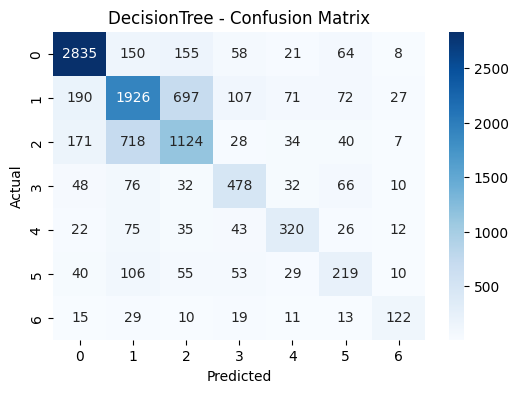


===== KNN =====
              precision    recall  f1-score   support

           0       0.55      0.98      0.71      3291
           1       0.56      0.47      0.51      3090
           2       0.46      0.37      0.41      2122
           3       0.73      0.21      0.33       742
           4       0.67      0.06      0.11       533
           5       0.48      0.08      0.13       512
           6       0.75      0.07      0.13       219

    accuracy                           0.54     10509
   macro avg       0.60      0.32      0.33     10509
weighted avg       0.56      0.54      0.49     10509



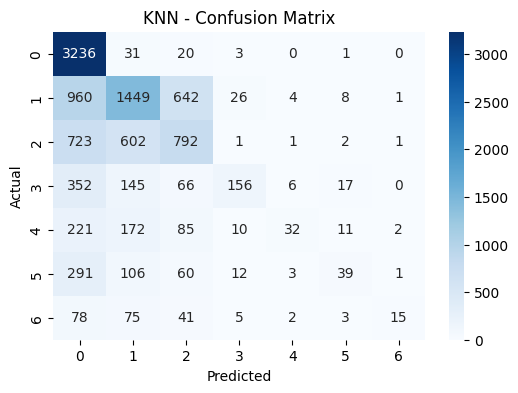


===== RandomForest =====
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      3291
           1       0.53      0.83      0.65      3090
           2       0.70      0.43      0.53      2122
           3       0.90      0.56      0.69       742
           4       0.96      0.45      0.61       533
           5       0.98      0.22      0.36       512
           6       0.99      0.34      0.51       219

    accuracy                           0.70     10509
   macro avg       0.85      0.53      0.60     10509
weighted avg       0.75      0.70      0.68     10509



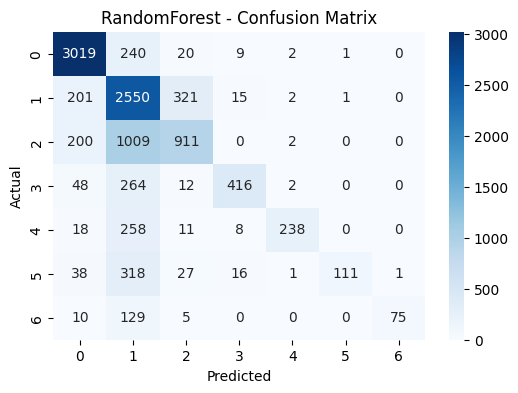


===== Bagging =====
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      3291
           1       0.63      0.71      0.67      3090
           2       0.63      0.53      0.58      2122
           3       0.69      0.71      0.70       742
           4       0.79      0.59      0.67       533
           5       0.58      0.39      0.47       512
           6       0.93      0.57      0.71       219

    accuracy                           0.71     10509
   macro avg       0.73      0.63      0.67     10509
weighted avg       0.71      0.71      0.71     10509



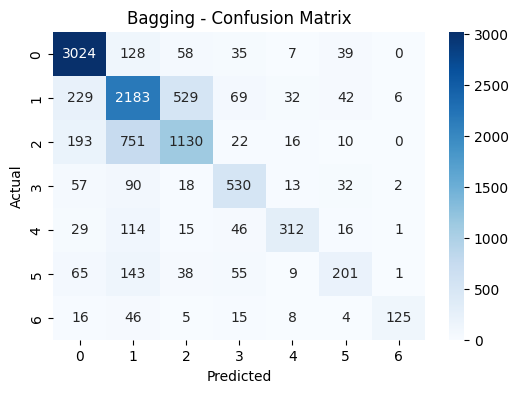


===== AdaBoost =====


d:\1Rohit\Mentalhealth\ml_env\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.73      0.93      0.82      3291
           1       0.61      0.62      0.61      3090
           2       0.64      0.50      0.56      2122
           3       0.61      0.57      0.59       742
           4       0.79      0.67      0.72       533
           5       0.61      0.29      0.39       512
           6       0.77      0.51      0.61       219

    accuracy                           0.67     10509
   macro avg       0.68      0.58      0.62     10509
weighted avg       0.67      0.67      0.66     10509



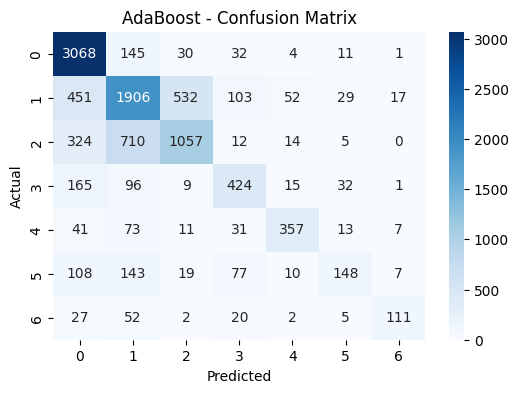


===== GradientBoosting =====
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      3291
           1       0.62      0.74      0.67      3090
           2       0.69      0.57      0.63      2122
           3       0.74      0.68      0.71       742
           4       0.89      0.68      0.77       533
           5       0.63      0.35      0.45       512
           6       0.84      0.48      0.61       219

    accuracy                           0.73     10509
   macro avg       0.75      0.63      0.67     10509
weighted avg       0.73      0.73      0.72     10509



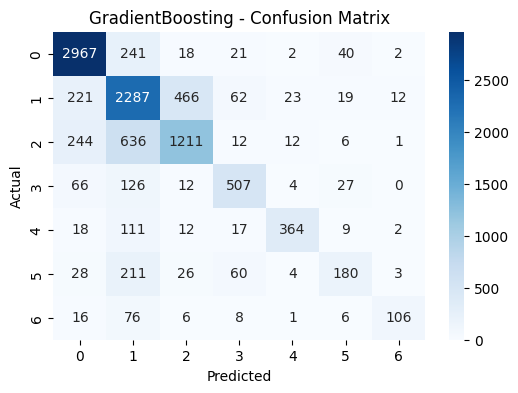

In [20]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # Train
    model.fit(xtrain_final, ytrain)
    
    # Predict
    y_pred = model.predict(xtest_final)
    
    # Accuracy
    acc = accuracy_score(ytest, y_pred)
    
    # Classification report
    report = classification_report(ytest, y_pred, output_dict=True)
    
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })
    
    # Print report
    print(classification_report(ytest, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(ytest, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [21]:
results

[{'Model': 'MultinomialNB',
  'Accuracy': 0.6988295746502997,
  'Precision': 0.6949342038876999,
  'Recall': 0.6988295746502997,
  'F1-score': 0.689646130491735},
 {'Model': 'BernoulliNB',
  'Accuracy': 0.6043391378818156,
  'Precision': 0.60814660340663,
  'Recall': 0.6043391378818156,
  'F1-score': 0.5878861292134638},
 {'Model': 'LogisticRegression',
  'Accuracy': 0.7524978589780188,
  'Precision': 0.7481418799370982,
  'Recall': 0.7524978589780188,
  'F1-score': 0.7495202118178913},
 {'Model': 'DecisionTree',
  'Accuracy': 0.6683794842515939,
  'Precision': 0.6674458894631535,
  'Recall': 0.6683794842515939,
  'F1-score': 0.667821832606935},
 {'Model': 'KNN',
  'Accuracy': 0.5442002093443715,
  'Precision': 0.5563930841923477,
  'Recall': 0.5442002093443715,
  'F1-score': 0.4929728807768719},
 {'Model': 'RandomForest',
  'Accuracy': 0.6965458178703968,
  'Precision': 0.7461163106346822,
  'Recall': 0.6965458178703968,
  'F1-score': 0.6827373250433081},
 {'Model': 'Bagging',
  'Accu

## 📊 Model Performance Observations

### 🔹 Overall Performance
- **Logistic Regression** performs the best with:
  - Accuracy ≈ **0.75**
  - F1-score ≈ **0.75**

- **Gradient Boosting** and **Bagging** are close competitors:
  - Gradient Boosting F1 ≈ **0.72**
  - Bagging F1 ≈ **0.71**

- **KNN** performs the worst:
  - F1-score ≈ **0.49**

---

## 🧠 Feature Engineering Insight
- Using **Bag of Words (CountVectorizer)** with only **~15000 features** still gives **strong performance (~75%)**

- This indicates:
  - Text data already contains **strong signal**
  - Even simple representations can perform well for this task

---

## ⚠️ Data Splitting Issues
- **Stratification was not used**
  - This can lead to **unequal class distribution** in train/test

- As a result:
  - Precision and Recall vary across classes
  - Some classes may be underrepresented in the test set

---

## ⚖️ Class Imbalance Observation
- No class balancing techniques were applied:
  - No `class_weight`
  - No resampling (SMOTE / undersampling)

### 👉 Despite this:
- Models still achieve **reasonable baseline performance**

### ❗ But:
- Likely biased toward **majority classes**
- Minority class predictions may be weak *(check confusion matrix)*

---

## 🌲 Model Behavior Insights

### ✅ Linear Models
- **Logistic Regression** performs best
- Works well with **high-dimensional sparse data (BoW)**

---

### 🌳 Tree-Based Models
- **Random Forest / Gradient Boosting / Bagging**
  - Perform decently but not better than Logistic Regression

- Likely because:
  - Sparse high-dimensional data is **not ideal for tree-based models**

---

### ⚠️ Distance-Based Models
- **KNN performs poorly**

- Reason:
  - High-dimensional sparse space → **distance becomes meaningless**

---

## 📉 Precision vs Recall Behavior
- Weighted precision ≈ recall for most models  

### ❗ However:
- Without stratification → **class-wise imbalance exists**

- Some classes likely have:
  - High precision but low recall  
  - Or vice versa  